# Discharge Curve Comparison: PyBaMM vs Lookup Tables vs Analytical

This notebook compares battery discharge voltage curves obtained from three approaches:

1. **PyBaMM Direct Simulation** (solid lines) - Full electrochemical model simulation
2. **Lookup Table Interpolation** (dashed lines) - Pre-computed table with 2D interpolation
3. **Analytical Model** (dotted lines) - Simple V = V_oc(SoC) - I*R formula

We compare curves at different discharge rates (C-rates): 1C, 2C, 5C, and 10C for a generic lithium-ion battery.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from evtoltools.common import Voltage, Resistance
from evtoltools.components.battery import (
    AnalyticalDischargeModel,
    load_lookup_table_from_data,
)
from evtoltools.components.battery.pybamm_utils import PyBaMMDischargeModel

## Check PyBaMM Availability

PyBaMM is an optional dependency. If not installed, we'll skip the PyBaMM curves.

In [7]:
try:
    import pybamm
    PYBAMM_AVAILABLE = True
    print(f"PyBaMM version {pybamm.__version__} is available")
except ImportError:
    PYBAMM_AVAILABLE = False
    print("PyBaMM not installed. PyBaMM curves will be skipped.")
    print("Install with: pip install pybamm")

PyBaMM version 25.12.1 is available


## Configuration

Define the C-rates and SoC range for our comparison.

In [8]:
# C-rates to compare
C_RATES = [1.0, 2.0, 5.0, 10.0]

# SoC range (5% to 95%)
soc_points = np.linspace(0.05, 0.95, 50)

# Colors for each C-rate
COLORS = {
    1.0: '#1f77b4',   # Blue
    2.0: '#ff7f0e',   # Orange
    5.0: '#2ca02c',   # Green
    10.0: '#d62728',  # Red
}

# Battery parameters (lithium-ion)
V_MAX = 4.2  # V
V_MIN = 2.8  # V
V_NOM = 3.7  # V
R_MOHM = 30  # mOhm
CAPACITY_AH = 5.0  # Ah

## Create Discharge Models

We create three types of models:
1. **PyBaMM Model**: Direct electrochemical simulation (if available)
2. **Lookup Table Model**: Pre-computed from `evtoltools/data/`
3. **Analytical Model**: Simple V = V_oc - I*R formula

In [9]:
# Create PyBaMM model (if available)
if PYBAMM_AVAILABLE:
    pybamm_model = PyBaMMDischargeModel(
        parameter_set='Chen2020',
        model_type='SPM'
    )
    print("PyBaMM model: Chen2020 SPM")
else:
    pybamm_model = None
    print("PyBaMM model: Not available")

# Load lookup table from data directory
lookup_model = load_lookup_table_from_data('lithium_ion')
print(f"Lookup table: {lookup_model.soc_points.shape[0]} SoC x {lookup_model.c_rate_points.shape[0]} C-rate points")

# Create analytical model
analytical_model = AnalyticalDischargeModel(
    v_max=Voltage(V_MAX, 'V'),
    v_min=Voltage(V_MIN, 'V'),
    v_nominal=Voltage(V_NOM, 'V'),
    internal_resistance=Resistance(R_MOHM, 'mohm'),
    capacity_ah=CAPACITY_AH
)
print(f"Analytical model: V_oc - I*R (R = {R_MOHM} mOhm)")

PyBaMM model: Chen2020 SPM
Lookup table: 24 SoC x 24 C-rate points
Analytical model: V_oc - I*R (R = 30 mOhm)


## Generate Discharge Curves

Compute voltage vs SoC for each C-rate using all three models.

In [10]:
pybamm_curves = {}
lookup_curves = {}
analytical_curves = {}

print("Generating discharge curves...")

for c_rate in C_RATES:
    print(f"  Processing {c_rate}C...")
    
    # PyBaMM curves (if available)
    if pybamm_model is not None:
        pybamm_voltages = []
        for soc in soc_points:
            v = pybamm_model.get_voltage(soc=soc, c_rate=c_rate)
            pybamm_voltages.append(v.in_units_of('V'))
        pybamm_curves[c_rate] = np.array(pybamm_voltages)
    
    # Lookup table curves
    v_lookup = lookup_model.get_voltage(soc=soc_points, c_rate=c_rate)
    lookup_curves[c_rate] = v_lookup.magnitude
    
    # Analytical curves
    v_analytical = analytical_model.get_voltage(soc=soc_points, c_rate=c_rate)
    analytical_curves[c_rate] = v_analytical.magnitude

print("Done!")

Generating discharge curves...
  Processing 1.0C...
  Processing 2.0C...
  Processing 5.0C...
  Processing 10.0C...
Done!


## Plot Comparison

Create a comparison plot with:
- **Solid lines**: PyBaMM simulation results
- **Dashed lines**: Lookup table interpolation
- **Dotted lines**: Analytical model (V = V_oc - I*R)
- **Colors**: Different C-rates

X-axis shows SoC from 100% to 0% (discharge direction).

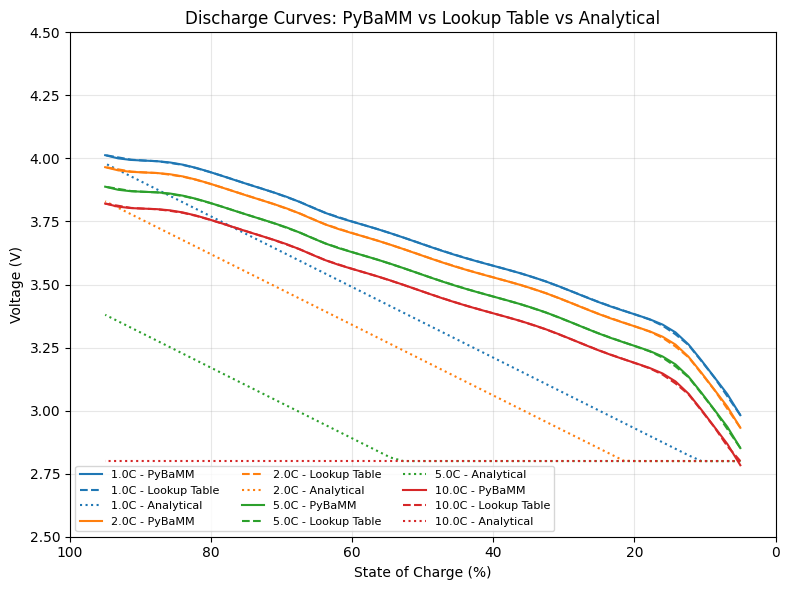

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

for c_rate in C_RATES:
    color = COLORS[c_rate]
    
    # PyBaMM (solid line)
    if c_rate in pybamm_curves:
        ax.plot(soc_points * 100, pybamm_curves[c_rate],
                '-', color=color, label=f'{c_rate}C - PyBaMM')
    
    # Lookup table (dashed line)
    ax.plot(soc_points * 100, lookup_curves[c_rate],
            '--', color=color, label=f'{c_rate}C - Lookup Table')
    
    # Analytical (dotted line)
    ax.plot(soc_points * 100, analytical_curves[c_rate],
            ':', color=color, label=f'{c_rate}C - Analytical')

ax.set_xlabel('State of Charge (%)')
ax.set_ylabel('Voltage (V)')
ax.set_title('Discharge Curves: PyBaMM vs Lookup Table vs Analytical')
ax.set_xlim(100, 0)  # Reversed: 100% to 0%
ax.set_ylim(2.5, 4.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

## Simplified Comparison Plot

A cleaner plot showing model types with C-rate labels.

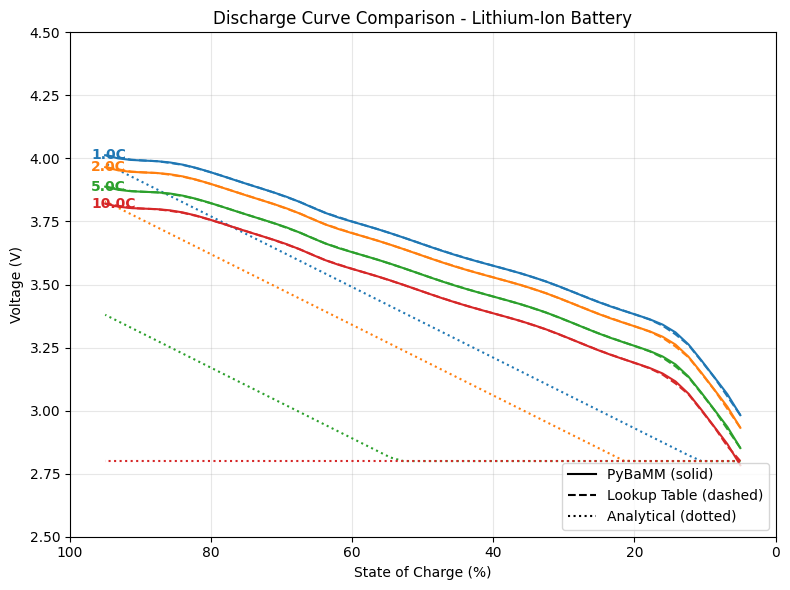

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

# Legend entries for line styles
if PYBAMM_AVAILABLE:
    ax.plot([], [], 'k-', label='PyBaMM (solid)')
ax.plot([], [], 'k--', label='Lookup Table (dashed)')
ax.plot([], [], 'k:', label='Analytical (dotted)')

for c_rate in C_RATES:
    color = COLORS[c_rate]
    
    if c_rate in pybamm_curves:
        ax.plot(soc_points * 100, pybamm_curves[c_rate], '-', color=color)
    ax.plot(soc_points * 100, lookup_curves[c_rate], '--', color=color)
    ax.plot(soc_points * 100, analytical_curves[c_rate], ':', color=color)

# C-rate labels at the left side (high SoC end, which is now on the left)
for c_rate in C_RATES:
    color = COLORS[c_rate]
    y_pos = lookup_curves[c_rate][-1]  # Value at high SoC
    ax.annotate(f'{c_rate}C', xy=(97, y_pos), fontsize=10,
                color=color, fontweight='bold', va='center')

ax.set_xlabel('State of Charge (%)')
ax.set_ylabel('Voltage (V)')
ax.set_title('Discharge Curve Comparison - Lithium-Ion Battery')
ax.set_xlim(100, 0)  # Reversed: 100% to 0%
ax.set_ylim(2.5, 4.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## Error Analysis

Calculate the difference between models.

In [13]:
print("Error Analysis: Lookup Table vs Analytical")
print("=" * 55)

for c_rate in C_RATES:
    diff = lookup_curves[c_rate] - analytical_curves[c_rate]
    max_error = np.max(np.abs(diff))
    mean_error = np.mean(np.abs(diff))
    rms_error = np.sqrt(np.mean(diff**2))
    
    print(f"\n{c_rate}C Discharge (Lookup - Analytical):")
    print(f"  Max Error:  {max_error*1000:.1f} mV")
    print(f"  Mean Error: {mean_error*1000:.1f} mV")
    print(f"  RMS Error:  {rms_error*1000:.1f} mV")

if PYBAMM_AVAILABLE:
    print("\n" + "=" * 55)
    print("Error Analysis: PyBaMM vs Others")
    print("=" * 55)
    
    for c_rate in C_RATES:
        lookup_diff = pybamm_curves[c_rate] - lookup_curves[c_rate]
        analytical_diff = pybamm_curves[c_rate] - analytical_curves[c_rate]
        
        print(f"\n{c_rate}C Discharge:")
        print(f"  Lookup vs PyBaMM RMS:     {np.sqrt(np.mean(lookup_diff**2))*1000:.1f} mV")
        print(f"  Analytical vs PyBaMM RMS: {np.sqrt(np.mean(analytical_diff**2))*1000:.1f} mV")

Error Analysis: Lookup Table vs Analytical

1.0C Discharge (Lookup - Analytical):
  Max Error:  462.8 mV
  Mean Error: 289.2 mV
  RMS Error:  312.8 mV

2.0C Discharge (Lookup - Analytical):
  Max Error:  547.7 mV
  Mean Error: 372.9 mV
  RMS Error:  391.0 mV

5.0C Discharge (Lookup - Analytical):
  Max Error:  767.8 mV
  Mean Error: 582.2 mV
  RMS Error:  605.0 mV

10.0C Discharge (Lookup - Analytical):
  Max Error:  1021.0 mV
  Mean Error: 652.5 mV
  RMS Error:  705.9 mV

Error Analysis: PyBaMM vs Others

1.0C Discharge:
  Lookup vs PyBaMM RMS:     1.9 mV
  Analytical vs PyBaMM RMS: 313.3 mV

2.0C Discharge:
  Lookup vs PyBaMM RMS:     1.9 mV
  Analytical vs PyBaMM RMS: 391.4 mV

5.0C Discharge:
  Lookup vs PyBaMM RMS:     2.0 mV
  Analytical vs PyBaMM RMS: 605.3 mV

10.0C Discharge:
  Lookup vs PyBaMM RMS:     3.1 mV
  Analytical vs PyBaMM RMS: 706.2 mV


## Individual C-Rate Comparison Plots

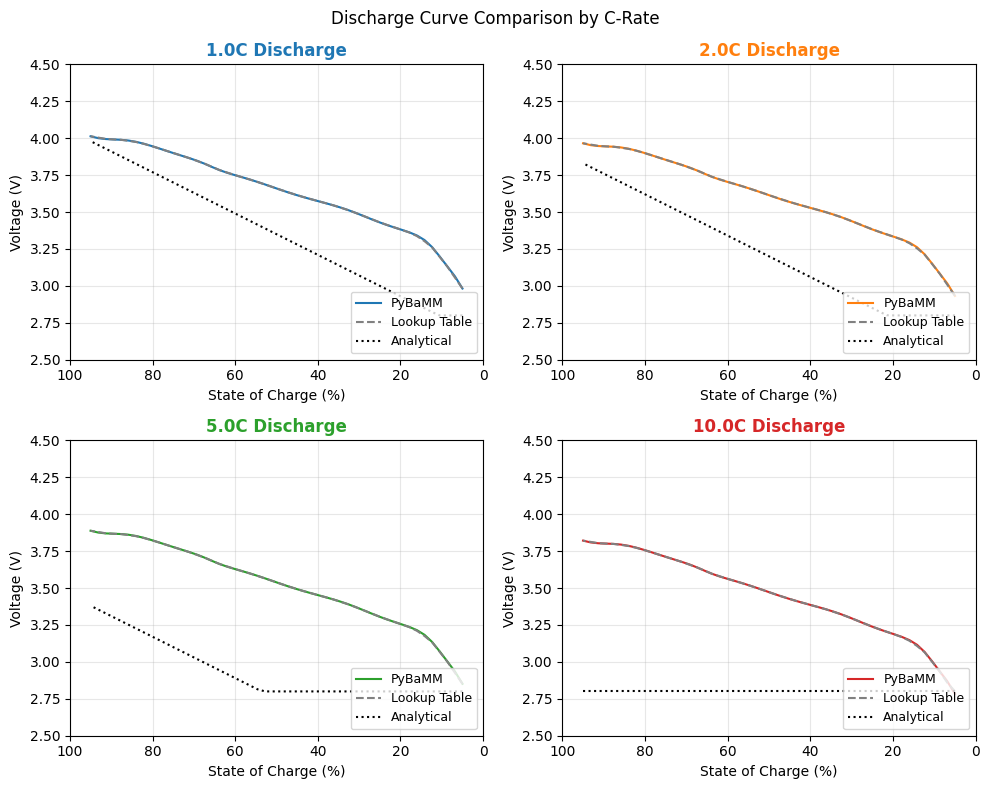

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, c_rate in enumerate(C_RATES):
    ax = axes[idx]
    color = COLORS[c_rate]
    
    if c_rate in pybamm_curves:
        ax.plot(soc_points * 100, pybamm_curves[c_rate], '-', color=color, label='PyBaMM')
    ax.plot(soc_points * 100, lookup_curves[c_rate], '--', color='gray', label='Lookup Table')
    ax.plot(soc_points * 100, analytical_curves[c_rate], ':', color='black', label='Analytical')
    
    ax.set_xlabel('State of Charge (%)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title(f'{c_rate}C Discharge', fontweight='bold', color=color)
    ax.set_xlim(100, 0)  # Reversed
    ax.set_ylim(2.5, 4.5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('Discharge Curve Comparison by C-Rate', fontsize=12)
plt.tight_layout()
plt.show()

## Model Characteristics Summary

| Model | Line Style | Speed | Accuracy | Use Case |
|-------|-----------|-------|----------|----------|
| PyBaMM | Solid | Slow (seconds/point) | High | Design validation |
| Lookup Table | Dashed | Fast (microseconds) | Medium | Mission simulation |
| Analytical | Dotted | Fastest | Low | Quick estimates |

## Generating Custom Lookup Tables

Generate custom lookup tables with arbitrary resolution using the utility script:

In [15]:
print("To generate custom lookup tables:")
print()
print("# Default settings (12 SoC points, 7 C-rate points)")
print("python utils/generate_lookup_tables.py")
print()
print("# High-resolution table")
print("python utils/generate_lookup_tables.py --soc-points 50 --c-rate-points 20")
print()
print("# Different chemistry")
print("python utils/generate_lookup_tables.py --chemistry lifepo4")
print()
print("# Use PyBaMM for accurate simulation")
print("python utils/generate_lookup_tables.py --use-pybamm --model-type SPM")

To generate custom lookup tables:

# Default settings (12 SoC points, 7 C-rate points)
python utils/generate_lookup_tables.py

# High-resolution table
python utils/generate_lookup_tables.py --soc-points 50 --c-rate-points 20

# Different chemistry
python utils/generate_lookup_tables.py --chemistry lifepo4

# Use PyBaMM for accurate simulation
python utils/generate_lookup_tables.py --use-pybamm --model-type SPM


## Summary

This notebook demonstrated:

1. **Three discharge model approaches**:
   - PyBaMM (solid lines): Full electrochemical simulation
   - Lookup Table (dashed lines): Pre-computed interpolation
   - Analytical (dotted lines): Simple V = V_oc - I*R

2. **Voltage curves** at multiple C-rates (1C, 2C, 5C, 10C)

3. **Trade-offs** between speed and accuracy for different use cases

4. **Custom table generation** using `utils/generate_lookup_tables.py`